# Per-Lead Analysis (good vs cut_lead)

Ten notebook wykrywa ucieta nozke przez analize lokalna 3 stref (left/center/right), a nie globalna sume bledu.

## Logika decyzji
`defect = left>X OR center>X OR right>X`

## Kolejnosc uruchamiania
1. Uruchom komorki od gory (Run All).
2. W komorce demo zmien `test_class` i `test_name` dla pojedynczego obrazu.
3. Uruchom batch eval i diagnostyke strefowa.
4. Uruchom tuning siatka, a potem finalna walidacje.
5. Przepisz najlepsze parametry do komorki konfiguracji na poczatku.

## Najwazniejsze parametry
- `LEAD_ZONE_START`: od jakiej wysokosci zaczyna sie strefa nozek.
- `EROSION_ITERATIONS`: erozja maski referencyjnej przed odejmowaniem.
- `MIN_ZONE_DEFECT_AREA`: prog pikseli bledu na pojedyncza strefe.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import model

# ===============================
# PER-LEAD ANALYSIS - PARAMETRY
# ===============================
LEAD_ZONE_START = 0.68
EROSION_ITERATIONS = 4
MIN_ZONE_DEFECT_AREA = 3000
MIN_COMPONENT_AREA = 25

# Dla MVP używamy OR: wada gdy dowolna strefa przekroczy próg.
DECISION_MODE = "any"

PROJECT_ROOT = Path.cwd()
REFERENCE_MASK = np.load("reference_mask_vote_0.50.npy").astype(np.uint8)

print("Notebook ustawiony na Per-Lead Analysis (3 strefy X).")

Notebook ustawiony na Per-Lead Analysis (3 strefy X).


In [2]:
def load_rgb(image_path):
    bgr = cv2.imread(str(image_path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise FileNotFoundError(f"Brak obrazu: {image_path}")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def cleanup_components(mask, min_area=MIN_COMPONENT_AREA):
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = np.zeros_like(mask)
    for i in range(1, n):
        if int(stats[i, cv2.CC_STAT_AREA]) >= int(min_area):
            out[labels == i] = 255
    return out

def get_alignment_params(ref_mask, test_mask):
    h, _ = ref_mask.shape
    roi_h = int(h * 0.5)
    ref_top = ref_mask[:roi_h, :]
    test_top = test_mask[:roi_h, :]

    M_ref = cv2.moments(ref_top)
    M_test = cv2.moments(test_top)
    if M_ref["m00"] == 0 or M_test["m00"] == 0:
        return 0, 0

    dx = int(M_ref["m10"] / M_ref["m00"] - M_test["m10"] / M_test["m00"])
    dy = int(M_ref["m01"] / M_ref["m00"] - M_test["m01"] / M_test["m00"])
    return dx, dy

def align_image(mask, dx, dy):
    rows, cols = mask.shape[:2]
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    return cv2.warpAffine(mask, M, (cols, rows), flags=cv2.INTER_NEAREST)

def compute_lead_zones(ref_mask, lead_zone_start=LEAD_ZONE_START):
    ys, xs = np.where(ref_mask > 0)
    if xs.size == 0:
        raise ValueError("Maska referencyjna jest pusta.")

    h, w = ref_mask.shape
    y0 = int(np.clip(int(h * lead_zone_start), 0, h - 1))
    x_min = int(xs.min())
    x_max = int(xs.max())
    if x_max <= x_min:
        raise ValueError("Niepoprawny zakres X maski referencyjnej.")

    width = x_max - x_min + 1
    t1 = x_min + width // 3
    t2 = x_min + (2 * width) // 3

    zones = {
        "left": (x_min, t1),
        "center": (t1, t2),
        "right": (t2, x_max + 1),
    }

    clipped = {}
    for name, (xa, xb) in zones.items():
        xa = int(np.clip(xa, 0, w))
        xb = int(np.clip(xb, 0, w))
        if xb <= xa:
            xb = min(w, xa + 1)
        clipped[name] = (xa, xb)

    return y0, clipped

In [3]:
def detect_cut_lead_per_zone(
    test_img_rgb,
    ref_mask,
    lead_zone_start=LEAD_ZONE_START,
    erosion_iterations=EROSION_ITERATIONS,
    min_zone_defect_area=MIN_ZONE_DEFECT_AREA,
    decision_mode=DECISION_MODE,
    min_component_area=MIN_COMPONENT_AREA,
    thresholds_by_zone=None,
    return_debug=True,
    ):
    test_mask = model._extract_transistor_mask(test_img_rgb)
    dx, dy = get_alignment_params(ref_mask, test_mask)
    aligned_mask = align_image(test_mask, dx, dy)

    if aligned_mask.shape != ref_mask.shape:
        h, w = ref_mask.shape
        aligned_mask = cv2.resize(aligned_mask, (w, h), interpolation=cv2.INTER_NEAREST)

    y0, zones = compute_lead_zones(ref_mask, lead_zone_start=lead_zone_start)
    kernel = np.ones((3, 3), np.uint8)

    ref_leads = ref_mask[y0:, :]
    test_leads = aligned_mask[y0:, :]
    ref_eroded = cv2.erode(ref_leads, kernel, iterations=int(erosion_iterations))
    diff_full = cv2.subtract(ref_eroded, test_leads)
    diff_full = cv2.morphologyEx(diff_full, cv2.MORPH_OPEN, kernel)
    diff_full = cleanup_components(diff_full, min_area=min_component_area)

    zone_pixels = {}
    zone_flags = {}
    zone_thresholds = {}
    zone_masks = {}

    for zone_name, (x0, x1) in zones.items():
        zone_view = diff_full[:, x0:x1].copy()
        zone_masks[zone_name] = zone_view
        pixels = int(np.count_nonzero(zone_view))
        thr = int(min_zone_defect_area) if thresholds_by_zone is None else int(thresholds_by_zone[zone_name])
        zone_pixels[zone_name] = pixels
        zone_thresholds[zone_name] = thr
        zone_flags[zone_name] = pixels > thr

    if decision_mode == "any":
        is_defective = bool(zone_flags["left"] or zone_flags["center"] or zone_flags["right"])
    elif decision_mode == "majority":
        is_defective = int(zone_flags["left"]) + int(zone_flags["center"]) + int(zone_flags["right"]) >= 2
    else:
        raise ValueError(f"Nieobsługiwany decision_mode: {decision_mode}")

    result = {
        "is_defective": bool(is_defective),
        "zone_pixels": zone_pixels,
        "zone_flags": zone_flags,
        "zone_thresholds": zone_thresholds,
        "y0": y0,
        "zones": zones,
        "dx": dx,
        "dy": dy,
    }

    if return_debug:
        result["aligned_mask"] = aligned_mask
        result["diff_full"] = diff_full

    return result

In [4]:
def _draw_zone_lines(ax, y0, zones):
    colors = {"left": "lime", "center": "cyan", "right": "yellow"}
    for zone_name, (x0, x1) in zones.items():
        ax.axvline(x=x0, color=colors[zone_name], linestyle="--", linewidth=1)
        ax.axvline(x=x1, color=colors[zone_name], linestyle="--", linewidth=1)
    ax.axhline(y=y0, color="orange", linestyle=":", linewidth=1)

def visualize_per_lead_result(img_rgb, ref_mask, result):
    y0 = result["y0"]
    zones = result["zones"]
    aligned = result["aligned_mask"]
    diff_full = result["diff_full"]

    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title(f"Oryginal | Defect={result['is_defective']}")
    axes[0, 0].axis("off")

    axes[0, 1].imshow(ref_mask, cmap="gray")
    _draw_zone_lines(axes[0, 1], y0, zones)
    axes[0, 1].set_title("Maska referencyjna + strefy")
    axes[0, 1].axis("off")

    axes[0, 2].imshow(aligned, cmap="gray")
    _draw_zone_lines(axes[0, 2], y0, zones)
    axes[0, 2].set_title("Maska testowa po wyrównaniu")
    axes[0, 2].axis("off")

    axes[1, 0].imshow(diff_full, cmap="hot")
    _draw_zone_lines(axes[1, 0], y0, zones)
    axes[1, 0].set_title("Mapa braków (full)")
    axes[1, 0].axis("off")

    for i, zone_name in enumerate(["left", "center", "right"]):
        zmask = result["diff_full"][:, zones[zone_name][0]:zones[zone_name][1]]
        pixels = result["zone_pixels"][zone_name]
        thr = result["zone_thresholds"][zone_name]
        flag = result["zone_flags"][zone_name]
        axes[1, i].imshow(zmask, cmap="hot")
        axes[1, i].set_title(f"{zone_name}: px={pixels}, thr={thr}, defect={flag}")
        axes[1, i].axis("off")

    plt.tight_layout()
    plt.show()

def print_zone_table(result):
    print("Per-Lead Summary")
    for zone_name in ["left", "center", "right"]:
        pixels = result["zone_pixels"][zone_name]
        thr = result["zone_thresholds"][zone_name]
        flag = result["zone_flags"][zone_name]
        print(f"  {zone_name:6s} | pixels={pixels:5d} | thr={thr:5d} | defect={flag}")
    print(f"Global decision ({DECISION_MODE}) => {result['is_defective']}")

Plik: 000.png | Klasa folderu: cut_lead
Per-Lead Summary
  left   | pixels= 3088 | thr= 3000 | defect=True
  center | pixels=   31 | thr= 3000 | defect=False
  right  | pixels= 2259 | thr= 3000 | defect=False
Global decision (any) => True


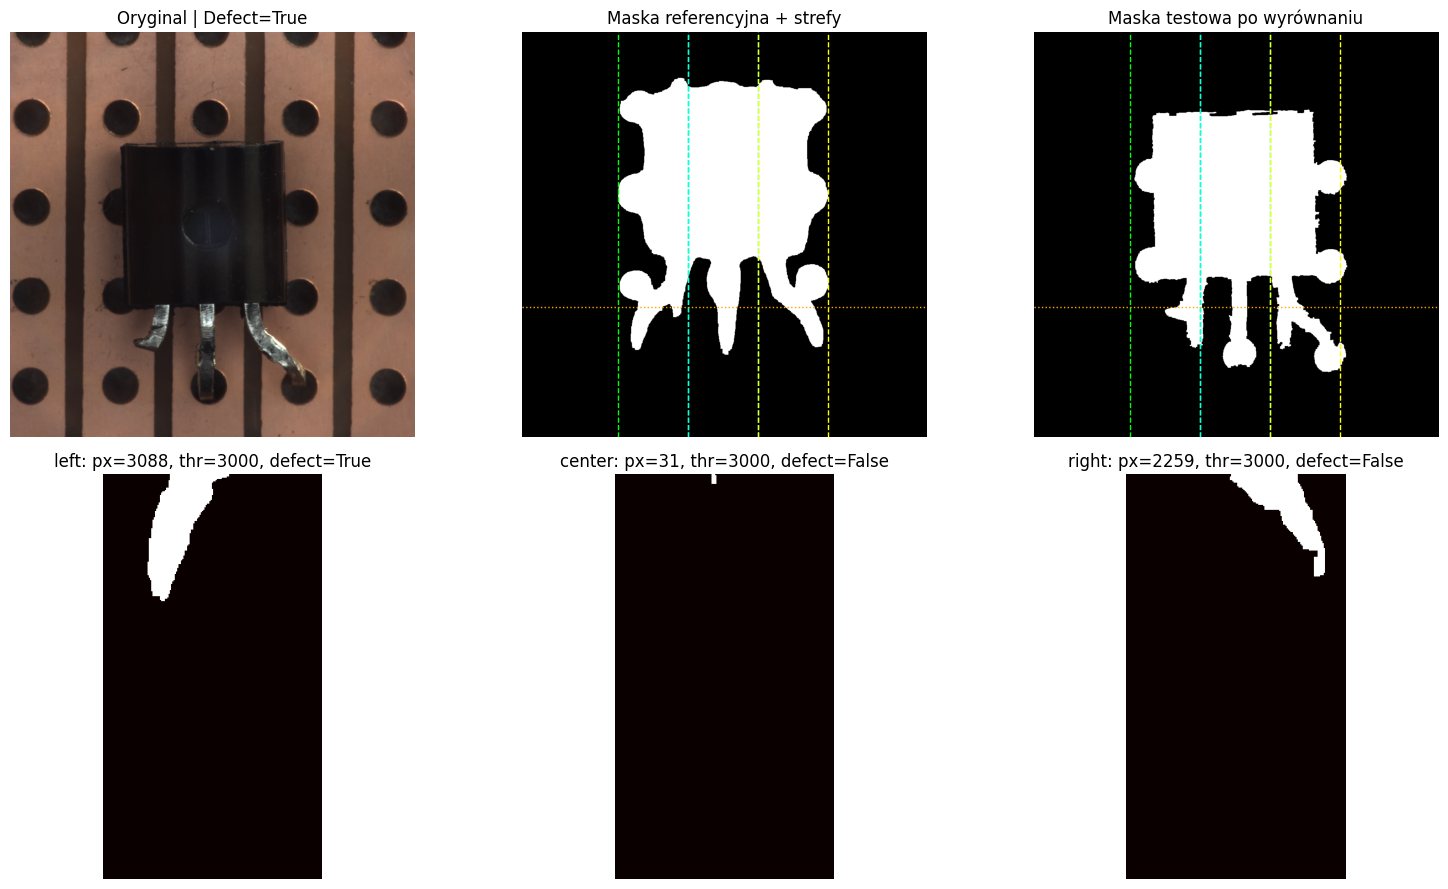

In [5]:
# DEMO: jeden obraz
test_class = "cut_lead"   # "good" albo "cut_lead"
test_name = "000.png"

test_path = PROJECT_ROOT / "transistor" / "test" / test_class / test_name
test_img = load_rgb(test_path)

demo_result = detect_cut_lead_per_zone(
    test_img,
    REFERENCE_MASK,
    lead_zone_start=LEAD_ZONE_START,
    erosion_iterations=EROSION_ITERATIONS,
    min_zone_defect_area=MIN_ZONE_DEFECT_AREA,
    decision_mode=DECISION_MODE,
    min_component_area=MIN_COMPONENT_AREA,
    return_debug=True,
    )

print(f"Plik: {test_path.name} | Klasa folderu: {test_class}")
print_zone_table(demo_result)
visualize_per_lead_result(test_img, REFERENCE_MASK, demo_result)

In [6]:
# BATCH EVAL: good vs cut_lead
def iter_class_files(class_name):
    folder = PROJECT_ROOT / "transistor" / "test" / class_name
    return sorted(folder.glob("*.png"))

def evaluate_classes(good_limit=None, cut_limit=None, config=None):
    if config is None:
        config = {
            "lead_zone_start": LEAD_ZONE_START,
            "erosion_iterations": EROSION_ITERATIONS,
            "min_zone_defect_area": MIN_ZONE_DEFECT_AREA,
            "decision_mode": DECISION_MODE,
            "min_component_area": MIN_COMPONENT_AREA,
        }

    rows = []
    for class_name, limit in [("good", good_limit), ("cut_lead", cut_limit)]:
        files = iter_class_files(class_name)
        if limit is not None:
            files = files[:limit]

        for p in files:
            img = load_rgb(p)
            res = detect_cut_lead_per_zone(
                img,
                REFERENCE_MASK,
                lead_zone_start=config["lead_zone_start"],
                erosion_iterations=config["erosion_iterations"],
                min_zone_defect_area=config["min_zone_defect_area"],
                decision_mode=config["decision_mode"],
                min_component_area=config["min_component_area"],
                return_debug=False,
            )

            rows.append({
                "class_name": class_name,
                "file_name": p.name,
                "pred": bool(res["is_defective"]),
                "gt": class_name == "cut_lead",
                "left_px": res["zone_pixels"]["left"],
                "center_px": res["zone_pixels"]["center"],
                "right_px": res["zone_pixels"]["right"],
                "left_def": res["zone_flags"]["left"],
                "center_def": res["zone_flags"]["center"],
                "right_def": res["zone_flags"]["right"],
            })

    return rows

def summarize_rows(rows, verbose=True):
    tp = sum(1 for r in rows if r["gt"] and r["pred"])
    tn = sum(1 for r in rows if (not r["gt"]) and (not r["pred"]))
    fp = sum(1 for r in rows if (not r["gt"]) and r["pred"])
    fn = sum(1 for r in rows if r["gt"] and (not r["pred"]))

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    tnr = tn / max(tn + fp, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-9)
    balanced = 0.5 * (recall + tnr)

    if verbose:
        print(f"TP={tp} TN={tn} FP={fp} FN={fn}")
        print(f"precision={precision:.3f} recall={recall:.3f} tnr={tnr:.3f} f1={f1:.3f} balanced={balanced:.3f}")

    return {
        "tp": tp, "tn": tn, "fp": fp, "fn": fn,
        "precision": precision, "recall": recall, "tnr": tnr,
        "f1": f1, "balanced": balanced,
    }

rows_quick = evaluate_classes(good_limit=10, cut_limit=None)
metrics_quick = summarize_rows(rows_quick, verbose=True)

TP=8 TN=10 FP=0 FN=1
precision=1.000 recall=0.889 tnr=1.000 f1=0.941 balanced=0.944



Klasa: good
  left   min=  607 max= 2475 mean=  1268.7
  center min=  161 max= 2230 mean=   877.6
  right  min=   73 max= 2104 mean=  1111.3

Klasa: cut_lead
  left   min=  387 max= 3433 mean=  2189.9
  center min=    0 max= 3509 mean=  1223.3
  right  min=  978 max= 3496 mean=  2460.3


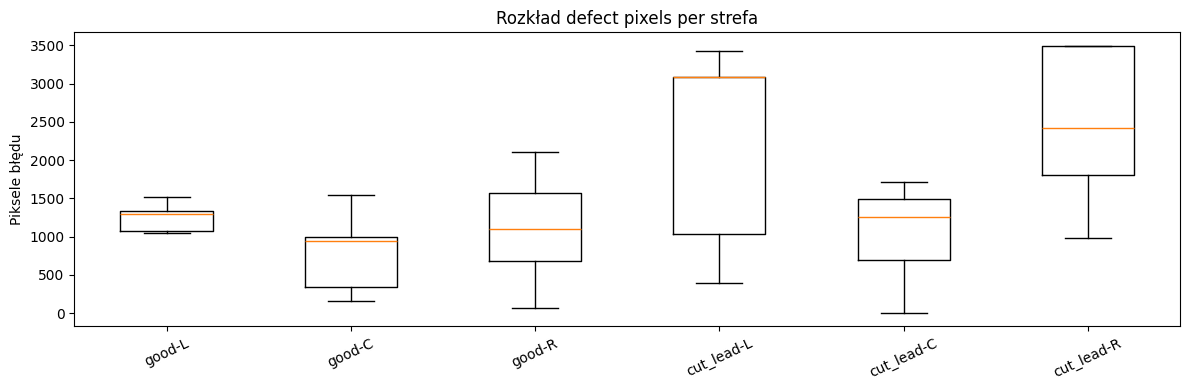

In [7]:
# DIAGNOSTYKA PER-STREFA (rozkłady pikseli błędu)
def collect_zone_values(rows, class_name):
    subset = [r for r in rows if r["class_name"] == class_name]
    left = np.array([r["left_px"] for r in subset], dtype=np.int32)
    center = np.array([r["center_px"] for r in subset], dtype=np.int32)
    right = np.array([r["right_px"] for r in subset], dtype=np.int32)
    return left, center, right

def print_zone_stats(rows):
    for cls in ["good", "cut_lead"]:
        left, center, right = collect_zone_values(rows, cls)
        print(f"\nKlasa: {cls}")
        for name, vals in [("left", left), ("center", center), ("right", right)]:
            print(f"  {name:6s} min={vals.min():5d} max={vals.max():5d} mean={vals.mean():8.1f}")

def plot_zone_distributions(rows):
    groups = []
    labels = []
    for cls in ["good", "cut_lead"]:
        left, center, right = collect_zone_values(rows, cls)
        groups.extend([left, center, right])
        labels.extend([f"{cls}-L", f"{cls}-C", f"{cls}-R"] )

    plt.figure(figsize=(12, 4))
    plt.boxplot(groups, tick_labels=labels, showfliers=False)
    plt.title("Rozkład defect pixels per strefa")
    plt.ylabel("Piksele błędu")
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()

print_zone_stats(rows_quick)
plot_zone_distributions(rows_quick)

In [8]:
# TUNING SIATKĄ (MVP: wspólny próg dla 3 stref)
def grid_search_per_lead():
    lead_zone_candidates = [0.58, 0.62, 0.65, 0.68, 0.72]
    erosion_candidates = [1, 2, 3, 4]
    threshold_candidates = [300, 600, 900, 1200, 1600, 2200, 3000]

    results = []
    for lz in lead_zone_candidates:
        for er in erosion_candidates:
            for thr in threshold_candidates:
                cfg = {
                    "lead_zone_start": lz,
                    "erosion_iterations": er,
                    "min_zone_defect_area": thr,
                    "decision_mode": "any",
                    "min_component_area": MIN_COMPONENT_AREA,
                }
                rows = evaluate_classes(config=cfg)
                m = summarize_rows(rows, verbose=False)
                results.append({
                    "lead_zone_start": lz,
                    "erosion_iterations": er,
                    "min_zone_defect_area": thr,
                    "balanced": m["balanced"],
                    "f1": m["f1"],
                    "fp": m["fp"],
                    "fn": m["fn"],
                })

    results = sorted(results, key=lambda r: (r["balanced"], r["f1"]), reverse=True)
    print("Top 10 konfiguracji:")
    for r in results[:10]:
        print(r)
    return results

grid_results = grid_search_per_lead()
best_config = grid_results[0]
print("\nBest config:", best_config)

KeyboardInterrupt: 

In [ ]:
# FINALNA WALIDACJA NA PEŁNYCH FOLDERACH (good + cut_lead)
final_cfg = {
    "lead_zone_start": best_config["lead_zone_start"],
    "erosion_iterations": best_config["erosion_iterations"],
    "min_zone_defect_area": best_config["min_zone_defect_area"],
    "decision_mode": "any",
    "min_component_area": MIN_COMPONENT_AREA,
}

rows_final = evaluate_classes(config=final_cfg)
metrics_final = summarize_rows(rows_final)

fp_files = [r["file_name"] for r in rows_final if (not r["gt"]) and r["pred"]]
fn_files = [r["file_name"] for r in rows_final if r["gt"] and (not r["pred"])]

print("\nFalse positives:", fp_files if fp_files else "brak")
print("False negatives:", fn_files if fn_files else "brak")
print("\nUstaw te wartości jako default w Cell 1:")
print(final_cfg)

TP=8 TN=42 FP=8 FN=1
precision=0.500 recall=0.889 tnr=0.840 f1=0.640 balanced=0.864

False positives: ['017.png', '018.png', '024.png', '025.png', '028.png', '040.png', '041.png', '044.png']
False negatives: ['005.png']

Ustaw te wartości jako default w Cell 1:
{'lead_zone_start': 0.68, 'erosion_iterations': 4, 'min_zone_defect_area': 3000, 'decision_mode': 'any', 'min_component_area': 25}


Plik: 003.png
Sciezka: c:\Coding\Sem_6\ZAW\CWP\Transformers\proj01\transistor\test\good\003.png
Predykcja: good (is_defective=False)
Per-Lead Summary
  left   | pixels= 1048 | thr= 3000 | defect=False
  center | pixels= 1545 | thr= 3000 | defect=False
  right  | pixels= 2104 | thr= 3000 | defect=False
Global decision (any) => False


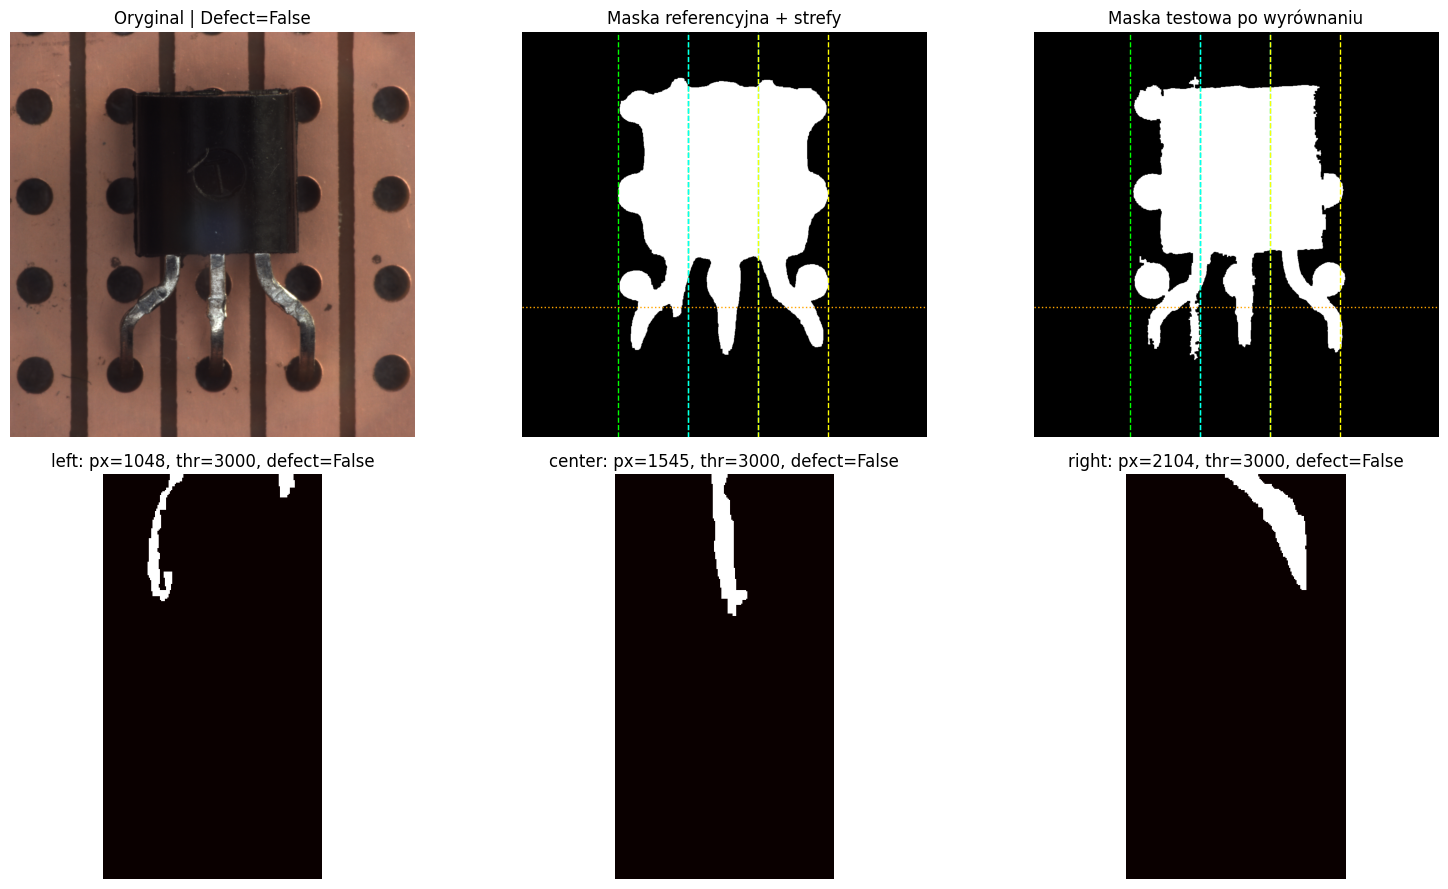

In [9]:
# SZYBKA KLASYFIKACJA JEDNEGO PLIKU (podaj tylko nazwe)
DEFAULT_CLASSIFY_CFG = {
    "lead_zone_start": 0.68,
    "erosion_iterations": 4,
    "min_zone_defect_area": 3000,
    "decision_mode": "any",
    "min_component_area": 25,
}

def resolve_input_image(file_name, class_name=None):
    direct = Path(file_name)
    if direct.exists():
        return direct

    test_root = PROJECT_ROOT / "transistor" / "test"
    if class_name is not None:
        candidate = test_root / class_name / file_name
        if candidate.exists():
            return candidate
        raise FileNotFoundError(f"Nie znaleziono pliku: {candidate}")

    matches = sorted(test_root.glob(f"**/{file_name}"))
    if not matches:
        raise FileNotFoundError(f"Nie znaleziono pliku {file_name} w {test_root}")
    if len(matches) > 1:
        print("Uwaga: znaleziono wiele plikow o tej nazwie. Uzywam pierwszego dopasowania:")
        for m in matches:
            print(f"  - {m.relative_to(test_root)}")
    return matches[0]

def classify_one_image(file_name, class_name=None, config=None, show_plot=True):
    if config is None:
        config = DEFAULT_CLASSIFY_CFG

    image_path = resolve_input_image(file_name, class_name=class_name)
    img = load_rgb(image_path)

    res = detect_cut_lead_per_zone(
        img,
        REFERENCE_MASK,
        lead_zone_start=config["lead_zone_start"],
        erosion_iterations=config["erosion_iterations"],
        min_zone_defect_area=config["min_zone_defect_area"],
        decision_mode=config["decision_mode"],
        min_component_area=config["min_component_area"],
        return_debug=True,
    )

    pred_label = "cut_lead" if res["is_defective"] else "good"
    print(f"Plik: {image_path.name}")
    print(f"Sciezka: {image_path}")
    print(f"Predykcja: {pred_label} (is_defective={res['is_defective']})")
    print_zone_table(res)

    if show_plot:
        visualize_per_lead_result(img, REFERENCE_MASK, res)

    return pred_label, res

# Przyklad uzycia:
pred_label, pred_result = classify_one_image("003.png", class_name="good")